In [1]:
import numpy as np
import matplotlib.pyplot as plt
from classy import Class
from matplotlib.ticker import LogLocator, NullFormatter, MultipleLocator, AutoMinorLocator

In [2]:
flag_save_plot = False

## SETUP: LCDM parameters and LCDM + MONOPOLES

In [3]:
# =======================
# CONFIG / GRID
# =======================
a_grid = np.logspace(-7, 0, 900)

# =======================
# BASE COSMOLOGY: Planck 2018 TT,TE,EE+lowE
# =======================
h_fixed     = 0.6727
theta_s_100 = 1.04090
omega_b     = 0.02236
omega_cdm0  = 0.1202
tau_reio    = 0.0544
A_s         = np.exp(3.045) * 1e-10
n_s         = 0.9649

base_params = {
    # "theta_s_100": theta_s_100,
    "h": h_fixed,
    "omega_b": omega_b,
    "omega_cdm": omega_cdm0,
    "A_s": A_s,
    "n_s": n_s,
    "tau_reio": tau_reio,

    # we only need background; output can be minimal
    # (still keep tCl if you want consistency with previous runs)
    "output": "tCl,lCl",
    "lensing": "yes",
    "l_max_scalars": 2500,
    "headers": "yes",
    "format": "camb",   # optional, gives μK^2-style outputs
}

# =======================
# PARAM BUILDERS
# =======================
def params_reference():
    p = dict(base_params)
    return p

def params_monopoles(f_mon, kappa_mon, a_t_mon):
    p = dict(base_params)
    p["f_mon"] = float(f_mon)
    p["kappa_mon"] = float(kappa_mon)
    p["a_t_mon"] = float(a_t_mon)
    return p

In [4]:
# =======================
# CLASSY RUNNER
# =======================
def compute_background_arrays_base(pars):
    """
    Returns:
      a_arr, H_arr (in 1/Mpc), plus optional rho arrays if present in background dict.
    """
    cosmo = Class()
    cosmo.set(pars)
    cosmo.compute()

    bg = cosmo.get_background()  # dict of numpy arrays
    # bg keys typically include: 'z', 'H [1/Mpc]', '(.)rho_cdm', '(.)rho_dcdm', '(.)rho_dr', ...
    z = bg["z"]
    a = 1.0/(1.0+z)

    # H key name can differ slightly across versions; try common ones:
    if "H [1/Mpc]" in bg:
        H = bg["H [1/Mpc]"]
    elif "H" in bg:
        H = bg["H"]
    else:
        raise KeyError(f"Could not find H in background keys: {list(bg.keys())[:50]}")

    rho_cdm  = bg.get("(.)rho_cdm", None)

    cosmo.struct_cleanup()
    cosmo.empty()
    return a, H, rho_cdm

def compute_background_arrays(pars):
    """
    Returns:
      a_arr, H_arr (in 1/Mpc), plus optional rho arrays if present in background dict.
    """
    cosmo = Class()
    cosmo.set(pars)
    cosmo.compute()

    bg = cosmo.get_background()  # dict of numpy arrays
    # bg keys typically include: 'z', 'H [1/Mpc]', '(.)rho_cdm', '(.)rho_dcdm', '(.)rho_dr', ...
    z = bg["z"]
    a = 1.0/(1.0+z)

    # H key name can differ slightly across versions; try common ones:
    if "H [1/Mpc]" in bg:
        H = bg["H [1/Mpc]"]
    elif "H" in bg:
        H = bg["H"]
    else:
        raise KeyError(f"Could not find H in background keys: {list(bg.keys())[:50]}")

    rho_dcdm = bg.get("(.)rho_mon", None)
    rho_dr   = bg.get("(.)rho_dr", None)
    rho_cdm  = bg.get("(.)rho_cdm", None)

    cosmo.struct_cleanup()
    cosmo.empty()
    return a, H, rho_cdm, rho_dcdm, rho_dr

def interp_on_log_a(a_src, y_src, a_tgt):
    x_src = np.log(a_src)
    x_tgt = np.log(a_tgt)
    order = np.argsort(x_src)
    return np.interp(x_tgt, x_src[order], y_src[order])

In [5]:
# =======================
# REFERENCE H(a)
# =======================
a_ref, H_ref, rho_cdm_ref = compute_background_arrays_base(params_reference())
H_ref_on = interp_on_log_a(a_ref, H_ref, a_grid)

## CDM + monopoles density profile

In [6]:
def plot_evolution_comoving_dm_density(
    f_mon,
    kappa_mon_arr,
    a_t_mon_arr,
    *,
    rho0=None,
    title=None,
    xlim=(1e-7, 1.0),
    ylim=(0.995, 1.105),
    legend_loc="lower left",
    savepath=None,
    return_fig=False,
    style_map=None,
):
    """
    Plot the evolution of the *total comoving DM density* in the monopole-decay model:
        y(a) = a^3 [rho_cdm(a) + rho_dcdm(a)] / rho_cdm^0

    where:
      - rho_cdm is the stable CDM density
      - rho_dcdm is the decaying (monopole) CDM-like component
      - rho_cdm^0 is today's stable CDM density used for normalization

    Parameters
    ----------
    Gamma0_arr : array-like of float
        List/array of Γ0 values to scan over.
        Interpretation depends on your CLASS implementation:
          - If you pass `Gamma0_mon` and CLASS uses it directly (in 1/Mpc), then Γ0 sets the decay scale.
          - If CLASS rescales internally, Γ0 is a dimensionless knob controlling the effective decay.

    Dlna_arr : array-like of float
        List/array of Δln a values controlling the *width* of the transition
        in your tanh gate:
            turn_on = 0.5 * (1 + tanh((ln a - ln a_t)/Δln a))
        Smaller Δln a → sharper turn-on.

    f_mon : float
        Excess fraction of CDM in the early universe (your convention):
            Omega_ini_dcdm = f_mon * Omega0_cdm
        So early-time comoving DM is (1 + f_mon) times the stable CDM,
        before conversion to DR.

    z_t : float
        Transition redshift defining the midpoint a_t = 1/(1+z_t)
        of the tanh gate.

    Keyword-only options
    --------------------
    rho0 : float, optional
        Normalization ρ_cdm^0. If None, uses global `rho_cdm_ref[-1]`.
        (Assumes you computed a ΛCDM reference background already.)

    title : str, optional
        Custom plot title. If None, a default title with a_t and f_mon is used.

    xlim, ylim : tuple
        Axis limits.

    legend_loc : str
        Matplotlib legend location.

    savepath : str, optional
        If provided, saves the figure to this path.

    return_fig : bool
        If True, returns (fig, ax) instead of only showing.

    style_map : dict, optional
        Map Δln a -> style dict, e.g. {0.2: dict(lw=2.4, ls='-')}
        If None, a reasonable default is used.

    Notes
    -----
    Requires the helper functions already defined in your notebook:
      - params_monopoles(f_mon, z_t, Dlna, Gamma0)
      - compute_background_arrays(params) -> (a, H, rho_cdm, rho_dcdm, rho_dr)
    and a reference array:
      - rho_cdm_ref (from a ΛCDM run), used to get rho_cdm_ref[-1].
    """

    # ---- normalize + validate inputs ----
    kappa_mon_arr = np.atleast_1d(kappa_mon_arr).astype(float)
    a_t_mon_arr  = np.atleast_1d(a_t_mon_arr).astype(float)

    if np.any(kappa_mon_arr <= 0):
        raise ValueError("All kappa_mon values must be > 0.")
    if np.any(a_t_mon_arr <= 0):
        raise ValueError("All a_t_mon a values must be > 0.")
    if not (f_mon >= 0):
        raise ValueError("f_mon must be >= 0.")

    # Reference stable-CDM comoving normalization
    if rho0 is None:
        try:
            rho0 = rho_cdm_ref[-1]
        except NameError:
            raise NameError("rho0 not provided and global rho_cdm_ref is not defined.")

    # ---- default style map ----
    if style_map is None:
        style_map = {
            0.05: dict(lw=2.6, ls='-'),
            0.10: dict(lw=2.6, ls='-'),
            0.20: dict(lw=2.6, ls='-'),
            0.40: dict(lw=2.6, ls='-'),
            0.80: dict(lw=2.6, ls='-'),
        }

    # ---- figure/axes ----
    fig, ax = plt.subplots(figsize=(7.2, 4.8))

    # ---- main loop ----
    for kappa in kappa_mon_arr:
        for a_t_mon in a_t_mon_arr:
            # print("Dlna:",Dlna)
            pars = params_monopoles(f_mon, kappa, a_t_mon)
            a_m, H_m, rho_cdm, rho_dcdm, rho_dr = compute_background_arrays(pars)

            if rho_dcdm is None or rho_cdm is None:
                raise RuntimeError(
                    "Missing rho_cdm or rho_dcdm in background output. "
                    "Check that your CLASS output includes '(.)rho_cdm' and '(.)rho_dcdm'."
                )

            # total comoving DM (stable + monopole)
            comov_tot = a_m**3 * (rho_cdm + rho_dcdm)
            y = comov_tot / rho0

            lab = rf"$\kappa={kappa:g}$, $a_t={a_t_mon:g}$"
            ax.plot(a_m, y, label=lab, **style_map.get(float(a_t_mon), dict(lw=2.4)))

    # ---- axes styling ----
    ax.set_xscale("log")
    ax.set_xlim(*xlim)
    ax.set_ylim(*ylim)

    ax.set_xlabel(r"$a$", fontsize=13)
    ax.set_ylabel(r"$a^3\,\rho_{\rm DM}(a)\,/\,\rho_{\rm cdm}^0$", fontsize=13)

    ax.xaxis.set_major_locator(LogLocator(base=10.0, numticks=9))
    ax.xaxis.set_minor_locator(LogLocator(base=10.0, subs=np.arange(2, 10)*0.1, numticks=100))
    ax.xaxis.set_minor_formatter(NullFormatter())

    ax.yaxis.set_major_locator(MultipleLocator(0.02))
    ax.yaxis.set_minor_locator(AutoMinorLocator(2))

    ax.tick_params(axis='both', which='major', direction='in', top=True, right=True,
                   length=6, width=1.0, labelsize=11)
    ax.tick_params(axis='both', which='minor', direction='in', top=True, right=True,
                   length=3, width=0.8)

    ax.legend(frameon=False, fontsize=10, loc=legend_loc, ncol=1)

    if title is None:
        title = rf"$f_{{\rm mon}}={f_mon}$"
    ax.set_title(title, fontsize=13, pad=10)

    fig.tight_layout()

    if savepath is not None:
        fig.savefig(savepath, dpi=200, bbox_inches="tight")

    plt.show()

    if return_fig:
        return fig, ax

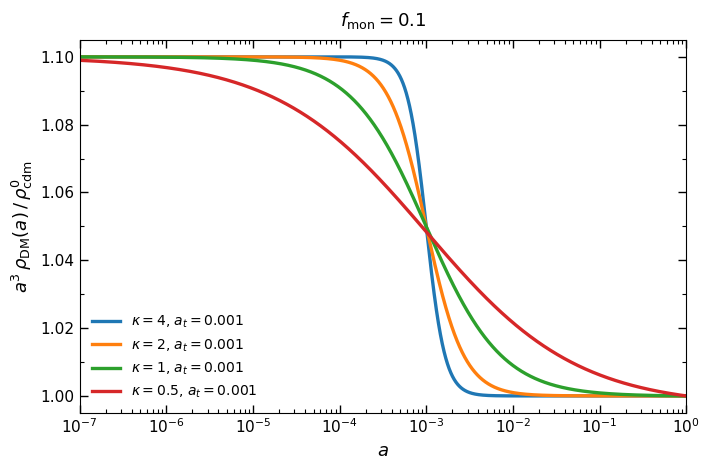

In [7]:
# =======================
# Plot settings
# =======================
f_mon = 0.1
kappa_mon_arr = [4, 2, 1, 0.5]
a_t_mon_arr   = [1e-3]

# --- make a plot
if flag_save_plot:
    plot_evolution_comoving_dm_density(f_mon, kappa_mon_arr, a_t_mon_arr, savepath="evolution_comoving_DM_1.pdf")
else:
    plot_evolution_comoving_dm_density(f_mon, kappa_mon_arr, a_t_mon_arr)

## DARK RADIATION profile

In [8]:
def plot_evolution_comoving_dr_density(
    f_mon,
    kappa_mon_arr,
    a_t_mon_arr,
    *,
    rho0=None,
    title=None,
    xlim=(1e-7, 1.0),
    ylim=(1e-9, 1e-2),
    legend_loc="upper left",
    savepath=None,
    return_fig=False,
    style_map=None,
):
    """
    Plot the evolution of the *comoving dark-radiation density* produced in the monopole-decay model:
        y(a) = a^4 rho_dr(a) / rho_cdm^0

    Parameters are analogous to your DM plot:
      - f_mon: early excess fraction (your convention)
      - kappa_mon_arr: list of kappa values
      - a_t_mon_arr: list of transition scale factors a_t
    """

    kappa_mon_arr = np.atleast_1d(kappa_mon_arr).astype(float)
    a_t_mon_arr   = np.atleast_1d(a_t_mon_arr).astype(float)

    if np.any(kappa_mon_arr <= 0):
        raise ValueError("All kappa_mon values must be > 0.")
    if np.any(a_t_mon_arr <= 0):
        raise ValueError("All a_t_mon values must be > 0.")
    if not (f_mon >= 0):
        raise ValueError("f_mon must be >= 0.")

    # Reference normalization
    if rho0 is None:
        try:
            rho0 = rho_cdm_ref[-1]
        except NameError:
            raise NameError("rho0 not provided and global rho_cdm_ref is not defined.")

    # Default style map (optional)
    if style_map is None:
        style_map = {float(at): dict(lw=2.6, ls='-') for at in np.unique(a_t_mon_arr)}

    fig, ax = plt.subplots(figsize=(7.2, 4.8))

    for kappa in kappa_mon_arr:
        for a_t_mon in a_t_mon_arr:
            pars = params_monopoles(f_mon, kappa, a_t_mon)
            a_m, H_m, rho_cdm, rho_dcdm, rho_dr = compute_background_arrays(pars)

            if rho_dr is None:
                raise RuntimeError(
                    "Missing rho_dr in background output. "
                    "Check that your CLASS output includes '(.)rho_dr' (or your DR variable)."
                )

            y = a_m**4 * rho_dr / rho0
            lab = rf"$\kappa={kappa:g}$"
            ax.plot(a_m, y, label=lab, **style_map.get(float(a_t_mon), dict(lw=2.4)))

    # Axes
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlim(*xlim)
    ax.set_ylim(*ylim)

    ax.set_xlabel(r"$a$", fontsize=13)
    ax.set_ylabel(r"$\rho_{\rm DR}\,a^4/\rho_{\rm cdm}^0$", fontsize=13)

    ax.xaxis.set_major_locator(LogLocator(base=10.0, numticks=9))
    ax.xaxis.set_minor_locator(LogLocator(base=10.0, subs=np.arange(2, 10)*0.1, numticks=100))
    ax.xaxis.set_minor_formatter(NullFormatter())

    ax.tick_params(axis='both', which='major', direction='in', top=True, right=True,
                   length=6, width=1.0, labelsize=11)
    ax.tick_params(axis='both', which='minor', direction='in', top=True, right=True,
                   length=3, width=0.8)

    ax.legend(frameon=False, fontsize=11, loc=legend_loc)

    if title is None:
        # mimic the annotation style from the paper figure
        # (they show a_t and zeta; here zeta ~ f_mon in your convention)
        title = rf"$a_t={a_t_mon_arr[0]:g},\ \zeta={f_mon:g}$"
    ax.set_title(title, fontsize=13, pad=10)

    fig.tight_layout()

    if savepath is not None:
        fig.savefig(savepath, dpi=200, bbox_inches="tight")

    plt.show()

    if return_fig:
        return fig, ax

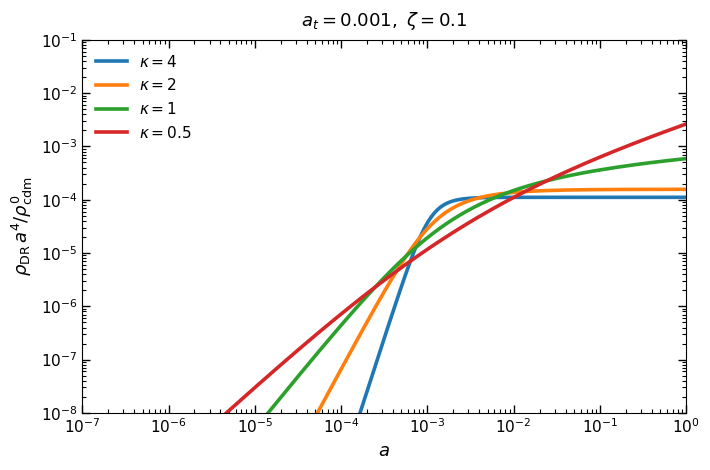

In [9]:
plot_evolution_comoving_dr_density(
    f_mon=0.1,
    kappa_mon_arr=[4, 2, 1, 0.5],
    a_t_mon_arr=[1e-3],
    ylim=(1e-8, 1e-1),
    xlim=(1e-7, 1.0),
    legend_loc="upper left",
)

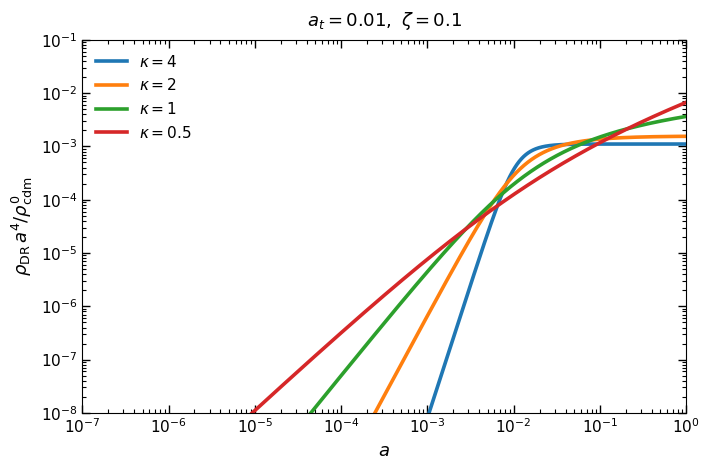

In [10]:
plot_evolution_comoving_dr_density(
    f_mon=0.1,
    kappa_mon_arr=[4, 2, 1, 0.5],
    a_t_mon_arr=[1e-2],
    ylim=(1e-8, 1e-1),
    xlim=(1e-7, 1.0),
    legend_loc="upper left",
)

## Evolution of Hubble rate

In [11]:
# --------------------------------------------------------------------
# Helper: compute H(a) interpolated on your global a_grid
# --------------------------------------------------------------------
def H_on_grid(pars, a_grid, *, use_base_runner=False):
    """
    Run CLASS and return H(a) interpolated on a_grid.
    """
    if use_base_runner:
        a, H, _ = compute_background_arrays_base(pars)
    else:
        a, H, *_ = compute_background_arrays(pars)
    return interp_on_log_a(a, H, a_grid)


# --------------------------------------------------------------------
# Reference: H^{zeta=0} on grid
# (you already computed this as H_ref_on; keep this if it exists)
# --------------------------------------------------------------------
# a_ref, H_ref, rho_cdm_ref = compute_background_arrays_base(params_reference())
# H_ref_on = interp_on_log_a(a_ref, H_ref, a_grid)


# --------------------------------------------------------------------
# FIG.2 LEFT: H/H_ref for fixed a_t, zeta(=f_mon), varying kappa
# --------------------------------------------------------------------
def plot_fig2_left_H_ratio(
    *,
    f_mon=0.1,
    a_t_mon=1e-3,
    kappa_list=(4, 2, 1, 0.5),
    xlim=(1e-7, 1.0),
    ylim=(0.998, 1.031),
    legend_loc="upper right",
    savepath=None,
):
    fig, ax = plt.subplots(figsize=(7.2, 4.8))

    for kappa in kappa_list:
        pars = params_monopoles(f_mon=f_mon, kappa_mon=kappa, a_t_mon=a_t_mon)
        H_m_on = H_on_grid(pars, a_grid)
        y = H_m_on / H_ref_on
        ax.plot(a_grid, y, lw=2.4, label=rf"$\kappa={kappa:g}$")

    ax.set_xscale("log")
    ax.set_xlim(*xlim)
    ax.set_ylim(*ylim)

    ax.set_xlabel(r"$a$", fontsize=13)
    ax.set_ylabel(r"$H\,/\,H^{\zeta=0}$", fontsize=13)

    # ticks like your previous plots
    ax.xaxis.set_major_locator(LogLocator(base=10.0, numticks=9))
    ax.xaxis.set_minor_locator(LogLocator(base=10.0, subs=np.arange(2, 10)*0.1, numticks=100))
    ax.xaxis.set_minor_formatter(NullFormatter())

    ax.yaxis.set_major_locator(MultipleLocator(0.005))
    ax.yaxis.set_minor_locator(AutoMinorLocator(5))

    ax.tick_params(axis='both', which='major', direction='in', top=True, right=True,
                   length=6, width=1.0, labelsize=11)
    ax.tick_params(axis='both', which='minor', direction='in', top=True, right=True,
                   length=3, width=0.8)

    # In-plot annotation like paper
    ax.text(0.03, 0.92, rf"$a_t=10^{{{int(np.log10(a_t_mon))}}},\ \zeta={f_mon:g}$",
            transform=ax.transAxes, fontsize=13)

    ax.legend(frameon=False, fontsize=11, loc=legend_loc)
    fig.tight_layout()

    if savepath is not None:
        fig.savefig(savepath, dpi=200, bbox_inches="tight")

    plt.show()
    return fig, ax


# --------------------------------------------------------------------
# Optional: constant ΔNeff reference curve (black dotted in right panel)
# --------------------------------------------------------------------
def params_constant_deltaNeff(delta_neff, *, base=None):
    """
    Make a reference model with constant extra radiation via N_eff.
    This is the closest CLASS-native analogue to "constant DR contribution".

    NOTE:
    - Depending on your CLASS build, you can use either 'N_eff' or 'N_ur'.
    - Most CLASS versions accept 'N_eff' directly.
    """
    if base is None:
        base = params_reference()

    p = dict(base)
    # safest: try N_eff. If your CLASS complains, switch to N_ur logic.
    p["N_ur"] = 3.046 + float(delta_neff)
    return p

# --------------------------------------------------------------------
# FIG.2 RIGHT: (H/H_ref - 1) for fixed kappa, varying a_t
# --------------------------------------------------------------------
def plot_fig2_right_H_minus1(
    *,
    f_mon=0.1,
    kappa=2.0,
    a_t_list=(5e-4, 5e-2, 5e-6),
    xlim=(1e-7, 1.0),
    ylim=(1e-5, 2e-1),
    legend_loc="upper left",
    add_constant_deltaNeff=None,   # e.g. 0.1 or 0.2
    savepath=None,
):
    fig, ax = plt.subplots(figsize=(7.2, 4.8))

    # main green family: change a_t
    for a_t_mon in a_t_list:
        pars = params_monopoles(f_mon=f_mon, kappa_mon=kappa, a_t_mon=a_t_mon)
        H_m_on = H_on_grid(pars, a_grid)

        y = H_m_on / H_ref_on - 1.0
        # keep positive-only for log scale (clip tiny negatives from interpolation noise)
        y = np.clip(y, 1e-30, None)

        ax.plot(a_grid, y, lw=2.6,
                label=rf"$a_t={a_t_mon:g}$")

        # ----------------------------------------------------------------
        # Placeholder for "produced DR alone" thin orange lines:
        # If you later implement a switch like `dr_only = yes`
        # (i.e. keep standard matter but inject the same DR history),
        # then compute it here and plot with e.g. color='C1', lw=1.6, ls='--'.
        # ----------------------------------------------------------------
        # pars_dr_only = params_monopoles(...); pars_dr_only["dr_only"] = "yes"
        # H_dr_only_on = H_on_grid(pars_dr_only, a_grid)
        # y_dr_only = np.clip(H_dr_only_on / H_ref_on - 1.0, 1e-30, None)
        # ax.plot(a_grid, y_dr_only, lw=1.5, ls='--')

    # constant ΔNeff dotted line
    if add_constant_deltaNeff is not None:
        parsN = params_constant_deltaNeff(add_constant_deltaNeff)
        HN_on = H_on_grid(parsN, a_grid, use_base_runner=True)
        yN = np.clip(HN_on / H_ref_on - 1.0, 1e-30, None)
        ax.plot(a_grid, yN, lw=2.0, ls=(0, (1.2, 3.0)), label=rf"const. $\Delta N_\mathrm{{eff}}={add_constant_deltaNeff:g}$")

    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlim(*xlim)
    ax.set_ylim(*ylim)

    ax.set_xlabel(r"$a$", fontsize=13)
    ax.set_ylabel(r"$H\,/\,H^{\zeta=0}-1$", fontsize=13)

    ax.xaxis.set_major_locator(LogLocator(base=10.0, numticks=9))
    ax.xaxis.set_minor_locator(LogLocator(base=10.0, subs=np.arange(2, 10)*0.1, numticks=100))
    ax.xaxis.set_minor_formatter(NullFormatter())

    ax.tick_params(axis='both', which='major', direction='in', top=True, right=True,
                   length=6, width=1.0, labelsize=11)
    ax.tick_params(axis='both', which='minor', direction='in', top=True, right=True,
                   length=3, width=0.8)

    # Paper-like annotation
    ax.text(0.68, 0.92, rf"$\kappa={kappa:g},\ \zeta={f_mon:g}$",
            transform=ax.transAxes, fontsize=13)

    ax.legend(frameon=False, fontsize=10, loc=legend_loc)
    fig.tight_layout()

    if savepath is not None:
        fig.savefig(savepath, dpi=200, bbox_inches="tight")

    plt.show()
    return fig, ax

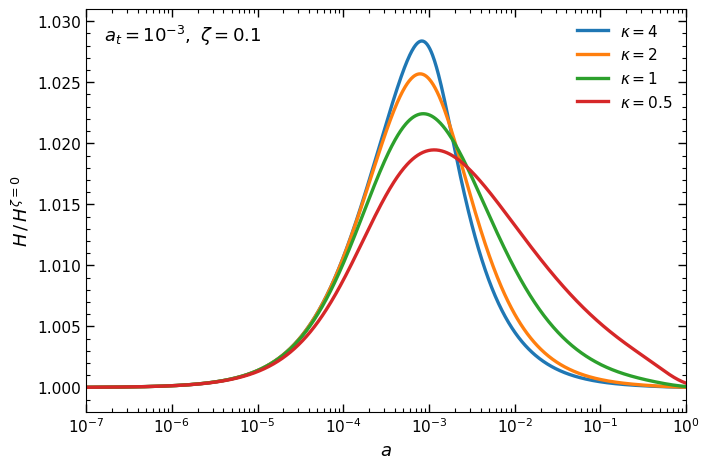

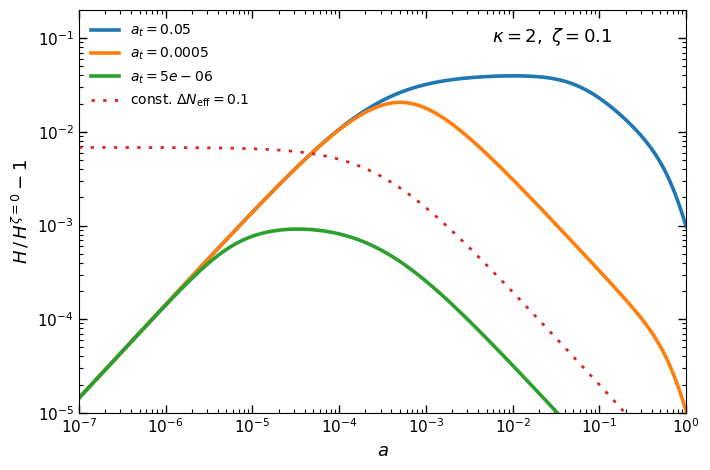

(<Figure size 720x480 with 1 Axes>,
 <Axes: xlabel='$a$', ylabel='$H\\,/\\,H^{\\zeta=0}-1$'>)

In [12]:
# Fig.2 left panel analogue
plot_fig2_left_H_ratio(
    f_mon=0.1,
    a_t_mon=1e-3,
    kappa_list=(4, 2, 1, 0.5),
    ylim=(0.998, 1.031),
)

# Fig.2 right panel analogue
plot_fig2_right_H_minus1(
    f_mon=0.1,
    kappa=2.0,
    a_t_list=(5e-2, 5e-4, 5e-6),
    ylim=(1e-5, 2e-1),
    add_constant_deltaNeff=0.1,   # tune to match the dotted line height
)


In [ ]:
# Fig.2 left panel analogue
plot_fig2_left_H_ratio(
    f_mon=0.1,
    a_t_mon=1e-1,
    kappa_list=(4, 2, 1, 0.5),
    ylim=(0.998, 1.045),
)